# Results of recording and subject LOO for binary classification for individual emotions

In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root_dir = "../../../"
results_root_dir = os.path.join(root_dir, "results/binary/")
results_dirs = {
    # "anger": "RETAIN_2026-02-12_19-05-24",
    # "disgust": "RETAIN_2026-02-12_19-19-45",
    # "sadness": "RETAIN_2026-02-12_19-34-11",
    # "tenderness": "RETAIN_2026-02-12_19-45-27",
    "tenderness-2": "2026-02-16_09-56-04",
    "sadness-2": "2026-02-16_12-49-49"
}
subdirs = ["recording_loo", "subject_loo"]
summary_file = "summary.csv"

## Load results

In [3]:
all_results = []
for emotion, dir_name in results_dirs.items():
    for subdir in subdirs:
        path = os.path.join(results_root_dir, dir_name, subdir, summary_file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["loo_type"] = subdir
            df["emotion"] = emotion
            # drop rows with "aggregated" under "metric_type"
            df = df[df["metric_type"] != "aggregated"]
            all_results.append(df)
        else:
            print(f"Warning: {path} not found, skipping.")

## Plot 

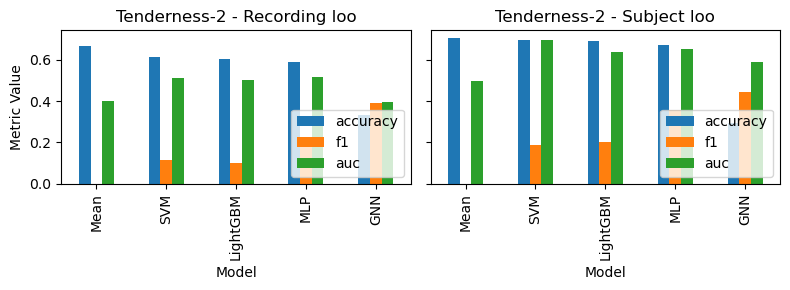

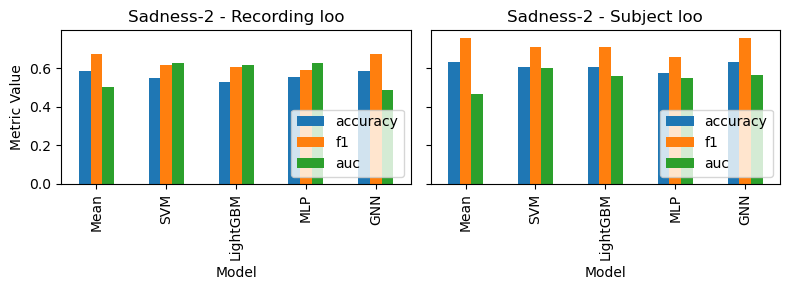

In [4]:
# for each emotion plot two barplots (one for recording_loo and one for subject_loo) showing the metrics (accuracy, f1, auc) for each model
for emotion in results_dirs.keys():
    emotion_results = pd.concat([df[df["emotion"] == emotion] for df in all_results])
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
    for i, subdir in enumerate(subdirs):
        subdir_results = emotion_results[emotion_results["loo_type"] == subdir]
        subdir_results.plot(x="model", y=["accuracy", "f1", "auc"], kind="bar", ax=axes[i])
        axes[i].set_title(f"{emotion.capitalize()} - {subdir.replace('_', ' ').capitalize()}")
        axes[i].set_xlabel("Model")
        axes[i].set_ylabel("Metric Value")
        axes[i].legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## Confusion matrices

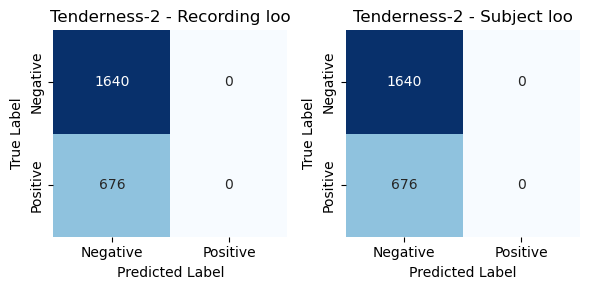

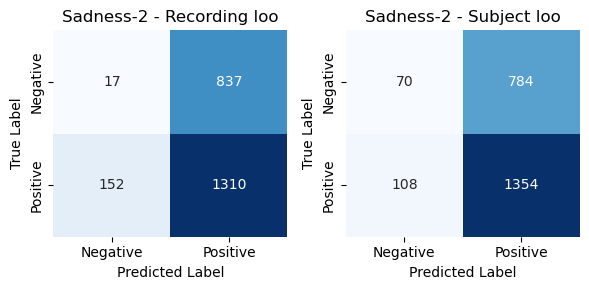

In [5]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import glob
from pathlib import Path

# For each emotion, plot confusion matrices for recording_loo and subject_loo
for emotion, dir_name in results_dirs.items():
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    
    for ax_idx, subdir in enumerate(subdirs):
        base_path = os.path.join(results_root_dir, dir_name, subdir)
        
        # Find all fold directories (r_1, r_2, ... or s_1, s_2, ...)
        fold_dirs = sorted(glob.glob(os.path.join(base_path, "[rs]_*")))
        
        # Aggregate all predictions and targets
        all_predictions = []
        all_targets = []
        
        for fold_dir in fold_dirs:
            pred_path = Path(os.path.join(fold_dir, "test_predictions.npy")).resolve()
            target_path = Path(os.path.join(fold_dir, "test_targets.npy")).resolve()

            # print(f"Checking for {pred_path} and {target_path}...")

            if os.path.exists(pred_path) and os.path.exists(target_path):
                preds = np.load(pred_path)
                targets = np.load(target_path)
                all_predictions.append(preds)
                all_targets.append(targets)

                # print("preds sample:", preds[:5])
                # print("targets sample:", targets[:5])
        
        if all_predictions and all_targets:
            # Concatenate all folds
            all_predictions = np.concatenate(all_predictions)
            all_targets = np.concatenate(all_targets)
            
            # Convert probabilities to class predictions
            pred_classes = (all_predictions > 0.5).astype(int)
            
            # Compute confusion matrix
            cm = confusion_matrix(all_targets, pred_classes)
            
            # Plot
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[ax_idx], 
                       cbar=False, xticklabels=["Negative", "Positive"], 
                       yticklabels=["Negative", "Positive"])
            axes[ax_idx].set_title(f"{emotion.capitalize()} - {subdir.replace('_', ' ').capitalize()}")
            axes[ax_idx].set_ylabel("True Label")
            axes[ax_idx].set_xlabel("Predicted Label")
    
    plt.tight_layout()
    plt.show()